In [4]:
import numpy as np
import matplotlib.pyplot as plt

!pip install numpy matplotlib

In [5]:
# -------------------------
# Data Generation
# -------------------------
def generate_data(n=100):
    # generate 100 random 2D points

    rng: np.random.Generator = np.random.default_rng()
    # standard normal distribution with mean 0 and std 1
    X: np.ndarray = rng.normal(loc=0.0, scale=1.0, size=(n, 2))

    # assign labels (-1 or +1)
    y: np.ndarray = np.zeros(n)
    for i in range(n):
        x1 = X[i, 0]
        x2 = X[i, 1]
        if x1 + x2 <= 0:
            y[i] = -1
        else:
            y[i] = 1

    return X, y

In [6]:
# -------------------------
# Loss Function
# -------------------------
def compute_loss(X, y, w: np.ndarray, b: float):
    # implement logistic loss
    loss = 0
    for i, point in enumerate(X):
        z = np.dot(w.transpose(), point) + b
        loss += np.log(1 + np.exp(-y[i] * z))

    # average all over n
    return loss / len(X)

In [7]:
# -------------------------
# Gradients
# -------------------------
def compute_gradients(X, y, w, b):
    n = len(X)
    dw = np.zeros(w.shape)
    db = 0
    # compute gradients dw and db
    for i, point in enumerate(X):
        u = -y[i] * (np.dot(w.transpose(), point) + b)
        log_derivative = np.exp(u) / (1 + np.exp(u))
        dw += log_derivative * (-y[i] * point)
        db += log_derivative * (-y[i])

    # average all over n
    dw /= n
    db /= n
    return dw, db

In [8]:
# -------------------------
# Gradient Descent
# -------------------------
def gradient_descent(X, y, lr=0.1, epochs=100):
    # initialize parameters
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        # compute gradients
        dw, db = compute_gradients(X, y, w, b)

        # update parameters
        w = w - lr * dw
        b = b - lr * db

    return w, b

In [9]:
# -------------------------
# Prediction
# -------------------------
def predict(X, w, b):
    # return predicted labels (-1 or +1)
    y_hat = np.zeros(X.shape[0])  # 100 points
    for i, point in enumerate(X):
        z = np.dot(w.transpose(), point) + b
        if z >= 0:
            y_hat[i] = 1
        else:
            y_hat[i] = -1
    return y_hat

In [10]:
# -------------------------
# Visualization
# -------------------------
def plot_decision_boundary(X, y, w, b):
    # plot points
    for i, point in enumerate(X):
        if y[i] == 1:
            plt.scatter(point[0], point[1], color="blue")
        else:
            plt.scatter(point[0], point[1], color="red")
    # plot decision boundary

    x1 = np.linspace(
        X[:, 0].min(), X[:, 0].max(), 100
    )  # 100 points between min and max of x1
    x2 = (
        -(w[0] * x1 + b) / w[1]
    )  # decision boundary: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b) / w2
    plt.plot(x1, x2, color="black", label="Decision Boundary")  # decision boundary
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.show()

Training accuracy: 0.98


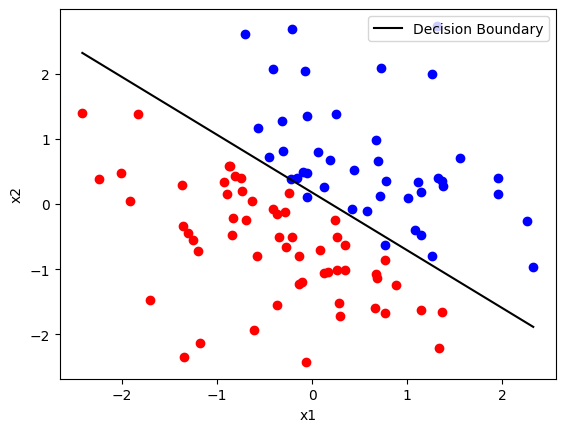

In [11]:
# -------------------------
# Main
# -------------------------
if __name__ == "__main__":
    X, y = generate_data()

    w, b = gradient_descent(X, y)

    preds = predict(X, w, b)
    acc = np.mean(preds == y)

    print("Training accuracy:", acc)

    plot_decision_boundary(X, y, w, b)